# 2022 MEPS: merge Prescribed Medicines (HC-239A) with Full Year Consolidated (HC-243)

Merge `h239a.xlsx` (Rx fill-level rows) with `h243.xlsx` (person-level traits) on **`DUPERSID`**.

In [1]:
import subprocess
import sys
from pathlib import Path

import pandas as pd


def ensure_packages(*specs: tuple[str, str]) -> None:
    for pip_name, import_name in specs:
        try:
            __import__(import_name)
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name, "-q"])


ensure_packages(
    ("python-calamine", "python_calamine"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
)

EXCEL_ENGINE = "calamine"


def resolve_meps_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "data" / "MEPS" / "excels",
        cwd / "data" / "MEPS",
        cwd / "MEPS" / "excels",
        cwd / "MEPS",
        cwd,
        cwd.parent / "data" / "MEPS" / "excels",
        cwd.parent / "data" / "MEPS",
        cwd.parent.parent / "data" / "MEPS" / "excels",
        cwd.parent.parent / "data" / "MEPS",
    ]
    for d in candidates:
        if d.exists() and any(d.glob("h239a.xlsx")):
            return d
    return candidates[0]


MEPS_DIR = resolve_meps_dir()
print(f"MEPS directory: {MEPS_DIR}")

MEPS directory: /Users/friana/Medical Adherence/data/MEPS


In [2]:
# HC-239A (2022): keep Rx fill identifiers, drug info, therapeutics, and payment components.
# Payment variables use the 2022 calendar-year suffix (*22X), not *23X.

H239A_COLS = [
    "DUPERSID",
    "RXRECIDX",
    "DRUGIDX",
    "LINKIDX",
    "RXNDC",
    "RXNAME",
    "RXDRGNAM",
    "TC1",
    "TC1S1",
    "TC1S1_1",
    "TC2",
    "TC3",
    "PURCHRD",
    "RXDAYSUP",
    "RXQUANTY",
    "RXSF22X",
    "RXXP22X",
    "RXMR22X",
    "RXMD22X",
    "RXPV22X",
    "RXOT22X",
    "RXFORM",
    "RXSTRENG",
    "RXSTRUNT",
]

h239a = pd.read_excel(
    MEPS_DIR / "h239a.xlsx",
    sheet_name=0,
    usecols=H239A_COLS,
    engine=EXCEL_ENGINE,
)

print(f"h239a shape: {h239a.shape}")
print(f"unique persons in h239a: {h239a['DUPERSID'].nunique():,}")
h239a.head()

h239a shape: (232605, 24)
unique persons in h239a: 13,602


,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,...,TC1S1,TC1S1_1,TC2,TC3,RXSF22X,RXMR22X,RXMD22X,RXPV22X,RXOT22X,RXXP22X
0,2460002101,2460002101002,2460002101002903001,2460002101002903,9,METOPROL TAR,METOPROLOL,72888000500,60.0,TABS,...,47,274,-1,-1,0.0,18.48,0.25,0.0,0.0,18.73
1,2460002101,2460002101002,2460002101002903002,2460002101002903,9,METOPROL TAR,METOPROLOL,72888000500,60.0,TABS,...,47,274,-1,-1,0.0,18.48,0.25,0.0,0.0,18.73
2,2460002101,2460002101003,2460002101003903001,2460002101003903,9,OMEPRAZOLE,OMEPRAZOLE,781223410,30.0,CPDR,...,272,-1,-1,-1,0.0,21.87,0.25,0.0,0.0,22.12
3,2460002101,2460002101003,2460002101003903002,2460002101003903,9,OMEPRAZOLE,OMEPRAZOLE,781223410,30.0,CPDR,...,272,-1,-1,-1,0.0,22.13,0.25,0.0,0.0,22.38
4,2460002101,2460002101004,2460002101004903001,2460002101004903,9,TRAZODONE,TRAZODONE,68382080505,30.0,TABS,...,249,306,-1,-1,0.0,17.68,0.25,0.0,0.0,17.93


In [3]:
h243 = pd.read_excel(
    MEPS_DIR / "h243.xlsx",
    sheet_name=0,
    engine=EXCEL_ENGINE,
)

# h243 is one row per person; h239a is one row per Rx fill (many rows per person)
merged_df = h239a.merge(h243, on="DUPERSID", how="left", validate="m:1")

print(f"h243 shape: {h243.shape}")
print(f"merged_df shape: {merged_df.shape}")
print(f"Rx rows without a matching person in h243: {merged_df['DATAYEAR'].isna().sum():,}")

merged_df.head()

h243 shape: (22431, 1420)
merged_df shape: (232605, 1443)
Rx rows without a matching person in h243: 0


,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,...,RXOSR22,RXPTR22,RXOTH22,PERWT22F,FAMWT22F,FAMWT22C,SAQWT22F,DIABW22F,VARSTR,VARPSU
0,2460002101,2460002101002,2460002101002903001,2460002101002903,9,METOPROL TAR,METOPROLOL,72888000500,60.0,TABS,...,0,0,0,5728.309495,5232.211986,5232.211986,3994.68714,6034.636755,2082,1
1,2460002101,2460002101002,2460002101002903002,2460002101002903,9,METOPROL TAR,METOPROLOL,72888000500,60.0,TABS,...,0,0,0,5728.309495,5232.211986,5232.211986,3994.68714,6034.636755,2082,1
2,2460002101,2460002101003,2460002101003903001,2460002101003903,9,OMEPRAZOLE,OMEPRAZOLE,781223410,30.0,CPDR,...,0,0,0,5728.309495,5232.211986,5232.211986,3994.68714,6034.636755,2082,1
3,2460002101,2460002101003,2460002101003903002,2460002101003903,9,OMEPRAZOLE,OMEPRAZOLE,781223410,30.0,CPDR,...,0,0,0,5728.309495,5232.211986,5232.211986,3994.68714,6034.636755,2082,1
4,2460002101,2460002101004,2460002101004903001,2460002101004903,9,TRAZODONE,TRAZODONE,68382080505,30.0,TABS,...,0,0,0,5728.309495,5232.211986,5232.211986,3994.68714,6034.636755,2082,1


# Age distribution by sex

Histogram of ages in the **2022** MEPS Rx cohort, color-coded for males and females (`SEX`: 1 = Male, 2 = Female). One row per person (deduped on `DUPERSID`).

### Bin choices

A one-year-per-bar chart has too many bars to read easily. Here we use **10-year age groups**, plus a separate **Under 20** band:

| Bin | Ages included | Why |
|-----|---------------|-----|
| Under 20 | 0–19 | Keeps children/young adults separate from working-age adults |
| 20–29 | 20–29 | Standard decade band |
| 30–39 … 70–79 | 30–39, etc. | Same 10-year width for comparison across mid/older life |
| 80+ | 80–85 | MEPS top-codes age at 85, so this is the oldest open-ended group |

Boundaries use **left-inclusive, right-exclusive** intervals (`right=False`), so age 20 falls in **20–29**, not Under 20.


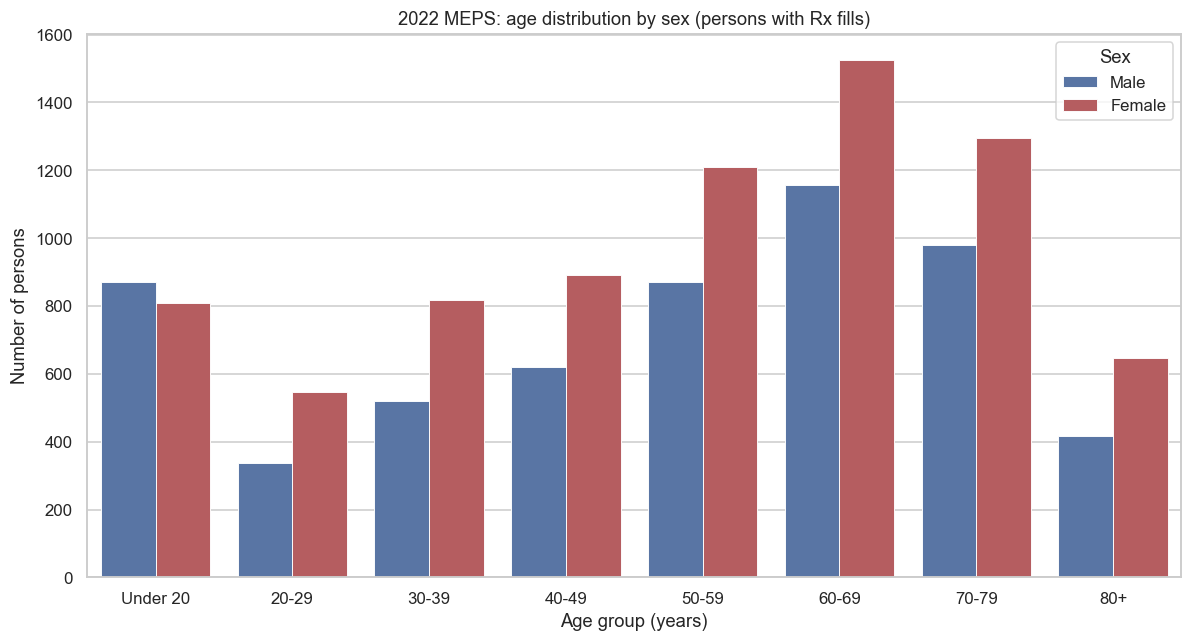

Sex,Female,Male,All
age_group,,,
Under 20,809,871,1680
20-29,545,336,881
30-39,818,521,1339
40-49,892,620,1512
50-59,1209,870,2079
60-69,1526,1157,2683
70-79,1294,979,2273
80+,646,416,1062
All,7739,5770,13509


In [4]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

AGE_BIN_EDGES = [0, 20, 30, 40, 50, 60, 70, 80, 86]
AGE_BIN_LABELS = [
    "Under 20", "20-29", "30-39", "40-49",
    "50-59", "60-69", "70-79", "80+",
]

person_demo = (
    merged_df[["DUPERSID", "SEX", "AGE22X"]]
    .drop_duplicates("DUPERSID")
    .loc[lambda d: d["AGE22X"].between(0, 85)]
    .assign(
        Sex=lambda d: d["SEX"].map({1: "Male", 2: "Female"}),
        age_group=lambda d: pd.cut(
            d["AGE22X"],
            bins=AGE_BIN_EDGES,
            labels=AGE_BIN_LABELS,
            right=False,
        ),
    )
    .dropna(subset=["Sex", "age_group"])
)

palette = {"Male": "#4C72B0", "Female": "#C44E52"}

fig, ax = plt.subplots(figsize=(11, 6))
sns.countplot(
    data=person_demo,
    x="age_group",
    hue="Sex",
    order=AGE_BIN_LABELS,
    hue_order=["Male", "Female"],
    palette=palette,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)

ax.set_title("2022 MEPS: age distribution by sex (persons with Rx fills)")
ax.set_xlabel("Age group (years)")
ax.set_ylabel("Number of persons")
ax.legend(title="Sex", frameon=True, loc="upper right")

plt.tight_layout()
plt.show()

pd.crosstab(person_demo["age_group"], person_demo["Sex"], margins=True)

## Therapeutic class columns (TC1, TC1S1, TC1S1_1, TC2, TC3)

Summary of **unique values** and data-quality flags (null / negative MEPS codes) at the **Rx fill** row level in `merged_df`. Segregation tables use the same age brackets as the histogram and person sex from HC-243.

In [5]:
import numpy as np

TC_COLS = ["TC1", "TC1S1", "TC1S1_1", "TC2", "TC3"]

AGE_BIN_EDGES = [0, 20, 30, 40, 50, 60, 70, 80, 86]
AGE_BIN_LABELS = [
    "Under 20", "20-29", "30-39", "40-49",
    "50-59", "60-69", "70-79", "80+",
]

tc_df = merged_df[["DUPERSID", "SEX", "AGE22X"] + TC_COLS].copy()
tc_df["Sex"] = tc_df["SEX"].map({1: "Male", 2: "Female"})
tc_df["age_group"] = pd.cut(
    tc_df["AGE22X"],
    bins=AGE_BIN_EDGES,
    labels=AGE_BIN_LABELS,
    right=False,
)

# MEPS uses negative integers for missing / not applicable (e.g. -1, -15)
def tc_value_status(series: pd.Series) -> pd.Series:
    return np.select(
        [series.isna(), series < 0, series >= 0],
        ["Null / missing", "Negative (invalid)", "Valid (>= 0)"],
        default="Other",
    )


def negative_code_label(val):
    if pd.isna(val):
        return "Null"
    if val < 0:
        return str(int(val))
    return "Valid (>= 0)"


tc_unique_rows = []
for col in TC_COLS:
    s = tc_df[col]
    neg_counts = s[s < 0].value_counts().sort_index()
    neg_detail = ", ".join(f"{int(k)}: {v:,}" for k, v in neg_counts.items()) or "—"
    valid_unique = s[s >= 0].nunique(dropna=True)

    tc_unique_rows.append(
        {
            "column": col,
            "unique_values_all": s.nunique(dropna=False),
            "unique_values_valid_only": valid_unique,
            "null_count": int(s.isna().sum()),
            "negative_count": int((s < 0).sum()),
            "valid_count": int((s >= 0).sum()),
            "negative_codes (count)": neg_detail,
        }
    )

tc_unique_summary = pd.DataFrame(tc_unique_rows).set_index("column")
print("Unique values and data-quality flags per TC column (Rx fill rows):")
display(tc_unique_summary)

Unique values and data-quality flags per TC column (Rx fill rows):


,unique_values_all,unique_values_valid_only,null_count,negative_count,valid_count,negative_codes (count)
column,,,,,,
TC1,18,17,0,6557,226048,"-15: 6,557"
TC1S1,100,98,0,12303,220302,"-15: 5,746, -1: 6,557"
TC1S1_1,119,117,0,85292,147313,"-15: 3,085, -1: 82,207"
TC2,13,12,0,224488,8117,"-1: 224,488"
TC3,4,3,0,232078,527,"-1: 232,078"


In [6]:
# Reference: Rx fill counts by sex and age bracket (same bins as histogram)
print(f"Total Rx fill rows: {len(tc_df):,}")
print(f"Rows with missing Sex: {tc_df['Sex'].isna().sum():,}")
print(f"Rows with missing age_group: {tc_df['age_group'].isna().sum():,}")

rx_by_sex = tc_df["Sex"].value_counts(dropna=False).rename_axis("Sex").to_frame("rx_fill_rows")
rx_by_age = tc_df["age_group"].value_counts(dropna=False).reindex(AGE_BIN_LABELS).rename_axis("age_group").to_frame("rx_fill_rows")

print("\nRx fills by sex:")
display(rx_by_sex)

print("\nRx fills by age bracket:")
display(rx_by_age)

print("\nRx fills by sex × age bracket:")
display(
    pd.crosstab(
        tc_df["age_group"],
        tc_df["Sex"],
        margins=True,
        dropna=False,
    ).reindex(AGE_BIN_LABELS + ["All"])
)

Total Rx fill rows: 232,605
Rows with missing Sex: 0
Rows with missing age_group: 814

Rx fills by sex:


,rx_fill_rows
Sex,
Female,138045
Male,94560



Rx fills by age bracket:


,rx_fill_rows
age_group,
Under 20,9843
20-29,7227
30-39,13698
40-49,22189
50-59,41343
60-69,60451
70-79,52794
80+,24246



Rx fills by sex × age bracket:


Sex,Female,Male,All
age_group,,,
Under 20,4744,5099,9843
20-29,4850,2377,7227
30-39,8911,4787,13698
40-49,13629,8560,22189
50-59,25761,15582,41343
60-69,34752,25699,60451
70-79,30652,22142,52794
80+,14285,9961,24246
All,138045,94560,232605


In [7]:
for col in TC_COLS:
    tmp = tc_df[["Sex", "age_group", col]].copy()
    tmp["value_status"] = tc_value_status(tmp[col])
    tmp["negative_code"] = tmp[col].apply(negative_code_label)

    print("=" * 72)
    print(f"{col} — value status by sex (Rx fill rows)")
    display(
        pd.crosstab(tmp["Sex"], tmp["value_status"], margins=True, dropna=False)
        .rename_axis(index="Sex", columns="value_status")
    )

    neg_only = tmp[tmp[col] < 0]
    if not neg_only.empty:
        print(f"{col} — negative codes by sex")
        display(
            pd.crosstab(neg_only["Sex"], neg_only["negative_code"], margins=True, dropna=False)
            .rename_axis(index="Sex", columns="negative_code")
        )

    print(f"{col} — value status by age bracket")
    display(
        pd.crosstab(tmp["age_group"], tmp["value_status"], margins=True, dropna=False)
        .reindex(AGE_BIN_LABELS + ["All"])
        .rename_axis(index="age_group", columns="value_status")
    )

    if not neg_only.empty:
        print(f"{col} — negative codes by age bracket")
        display(
            pd.crosstab(neg_only["age_group"], neg_only["negative_code"], margins=True, dropna=False)
            .reindex(AGE_BIN_LABELS + ["All"])
            .rename_axis(index="age_group", columns="negative_code")
        )

TC1 — value status by sex (Rx fill rows)


value_status,Negative (invalid),Valid (>= 0),All
Sex,,,
Female,3564,134481,138045
Male,2993,91567,94560
All,6557,226048,232605


TC1 — negative codes by sex


negative_code,-15,All
Sex,,
Female,3564,3564
Male,2993,2993
All,6557,6557


TC1 — value status by age bracket


...

negative_code,-1,All
Sex,,
Female,137748,137748
Male,94330,94330
All,232078,232078


TC3 — value status by age bracket


value_status,Negative (invalid),Valid (>= 0),All
age_group,,,
Under 20,9799,44,9843
20-29,7197,30,7227
30-39,13681,17,13698
40-49,22151,38,22189
50-59,41270,73,41343
60-69,60291,160,60451
70-79,52695,99,52794
80+,24181,65,24246
All,232078,527,232605


TC3 — negative codes by age bracket


negative_code,-1,All
age_group,,
Under 20,9799,9799
20-29,7197,7197
30-39,13681,13681
40-49,22151,22151
50-59,41270,41270
60-69,60291,60291
70-79,52695,52695
80+,24181,24181
All,232078,232078


## Rows for a specific LINKIDX (2022)

Filter **2022** prescribed-medicine fills (`h239a` / `merged_df`) where `LINKIDX` matches the target value. Each row is one Rx fill, with person-level traits from `h243` merged in.

In [9]:
LINKIDX_TARGET = 2460002101002903

linkidx_mask = (
    pd.to_numeric(merged_df["LINKIDX"], errors="coerce").astype("Int64") == LINKIDX_TARGET
)
linkidx_rows = merged_df.loc[linkidx_mask].copy()

print(f"2022 rows with LINKIDX == {LINKIDX_TARGET}: {len(linkidx_rows):,}")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.width", None)

linkidx_rows

2022 rows with LINKIDX == 2460002101002903: 2


,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXSTRENG,RXSTRUNT,RXDAYSUP,TC1,TC1S1,TC1S1_1,TC2,TC3,RXSF22X,RXMR22X,RXMD22X,RXPV22X,RXOT22X,RXXP22X,DUID,PID,PANEL,DATAYEAR,FAMID31,FAMID42,FAMID53,FAMID22,FAMIDYR,CPSFAMID,FCSZ1231,FCRP1231,RULETR31,RULETR42,RULETR53,RULETR22,RUSIZE31,RUSIZE42,RUSIZE53,RUSIZE22,RUCLAS31,RUCLAS42,RUCLAS53,RUCLAS22,FAMSZE31,FAMSZE42,FAMSZE53,FAMSZE22,FMRS1231,FAMS1231,FAMSZEYR,FAMRFPYR,REGION31,REGION42,REGION53,REGION22,REFPRS31,REFPRS42,REFPRS53,REFPRS22,RESP31,RESP42,RESP53,RESP22,PROXY31,PROXY42,PROXY53,PROXY22,INTVLANG,INTVTYPE31,INTVTYPE42,INTVTYPE53,BEGRFM31,BEGRFY31,ENDRFM31,ENDRFY31,BEGRFM42,BEGRFY42,ENDRFM42,ENDRFY42,BEGRFM53,BEGRFY53,ENDRFM53,ENDRFY53,ENDRFM22,ENDRFY22,KEYNESS,INSCOP31,INSCOP42,INSCOP53,INSCOP22,INSC1231,INSCOPE,ELGRND31,ELGRND42,ELGRND53,ELGRND22,PSTATS31,PSTATS42,PSTATS53,RURSLT31,RURSLT42,RURSLT53,AGE31X,AGE42X,AGE53X,AGE22X,AGELAST,DOBMM,DOBYY,SEX,RACEV1X,RACEV2X,RACEAX,RACEBX,RACEWX,RACETHX,HISPANX,HISPNCAT,MARRY31X,MARRY42X,MARRY53X,MARRY22X,SPOUID31,SPOUID42,SPOUID53,SPOUID22,SPOUIN31,SPOUIN42,SPOUIN53,SPOUIN22,EDUCYR,HIDEG,FTSTU31X,FTSTU42X,FTSTU53X,FTSTU22X,ACTDTY31,ACTDTY42,ACTDTY53,REFRL31X,REFRL42X,REFRL53X,REFRL22X,OTHLGSPK,WHTLGSPK,HWELLSPK,BORNUSA,YRSINUS,MOPID31X,MOPID42X,MOPID53X,DAPID31X,DAPID42X,DAPID53X,HIBPDX,HIBPAGED,BPMLDX,CHDDX,CHDAGED,ANGIDX,ANGIAGED,MIDX,MIAGED,OHRTDX,OHRTAGED,OHRTTYPE,STRKDX,STRKAGED,EMPHDX,EMPHAGED,CHBRON31,CHOLDX,CHOLAGED,CANCERDX,CABLADDR,CABREAST,CACERVIX,CACOLON,CALUNG,CALYMPH,CAMELANO,CAOTHER,CAPROSTA,CASKINNM,CASKINDK,CAUTERUS,DIABDX_M18,DIABAGED,JTPAIN31_M18,ARTHDX,ARTHTYPE,ARTHAGED,ASTHDX,ASTHAGED,ASSTIL31,ASATAK31,ASTHEP31,ASACUT31,ASMRCN31,ASPREV31,ASDALY31,ASPKFL31,ASEVFL31,ASWNFL31,ADHDADDX,ADHDAGED,COVIDEVER53,LCEVER53,COVSYMNOW53,COVREDABIL53,COVID12MO53,COVMNTHX53,COVYRDX53,RTHLTH31,RTHLTH42,RTHLTH53,MNHLTH31,MNHLTH42,MNHLTH53,IADLHP31,ADLHLP31,AIDHLP31,WLKLIM31,LFTDIF31,STPDIF31,WLKDIF31,MILDIF31,STNDIF31,BENDIF31,RCHDIF31,FNGRDF31,ACTLIM31,WRKLIM31,HSELIM31,SCHLIM31,UNABLE31,SOCLIM31,COGLIM31,DFHEAR42,DFSEE42,DFCOG42,DFWLKC42,DFDRSB42,DFERND42,ANYLMI22,CHPMED42,CHPMHB42,CHPMCN42,CHSERV42,CHSRHB42,CHSRCN42,CHLIMI42,CHLIHB42,CHLICO42,CHTHER42,CHTHHB42,CHTHCO42,CHCOUN42,CHEMPB42,CSHCN42,MESHGT42,WHNHGT42,MESWGT42,WHNWGT42,CHBMIX42,MESVIS42,EATHLT42,WHNEAT42,PHYSCL42,WHNPHY42,SAFEST42,WHNSAF42,BOOST42,WHNBST42,LAPBLT42,WHNLAP42,HELMET42,WHNHEL42,NOSMOK42,WHNSMK42,TIMALN42,LSTETH53,PHYEXE53,OFTSMK53,COVAXEVR31,COVAXEVR42,COVAXEVR53,BOOSTERSHOT31,BOOSTERSHOT42,COVAXNEW53,SAQELIG,ADPROX42,ADSEX42,ADAGE42,ADGENH42,ADDAYA42,ADCLIM42,ADACLS42,ADWKLM42,ADEMLS42,ADMWCF42,ADPAIN42,ADPCFL42,ADENGY42,ADPRST42,ADSOCA42,ADCOMPAN42,ADLEFTOUT42,ADISOL42,ADNERV42,ADHOPE42,ADREST42,ADSAD42,ADEFRT42,ADWRTH42,K6SUM42,ADINTR42,ADDPRS42,PHQ242,ADSLEEP42,ADDAYEXER42,ADMINSEXER42,ADASKALC42,ADNUMDRK42,ADRNK542_M20,ADRNK442_M20,ADOFTALC42,ADSTAL42,ADMNTRT42,ADUNABTRT42,ADPROBTRT42,ADTRTEXP42,ADLATERENT42,ADLATEUTIL42,ADMISSCCLN42,ADDEBT42,ADUNEXPEXP42,ADBRTC42,ADMDVT42,ADFLST42,ADWGHD42,ADWTAD42,ADTBAC42,ADOFTB42,ADQTTB42,ADQTMD42,ADQTHP42,ADMOOD42,ADBPCK42,ADCHLC42,ADPNEU42,ADSHNG42,ADNOAP42,ADDSCU42,ADCOLN42,ADCLNS42,ADSGMD42,ADBLDS42,ADPROS42,ADPSAG42,ADUTRM42,ADPAP42,ADPAPG42,ADOSTP42,ADBNDN42,ADBRST42,ADMMGR42,VPCS42,VMCS42,VRFLAG42,ADCMPM42,ADCMPY42,ADLANG42,ADBMI42,DCSELIG,DSDIA53,DSA1C53,DSFT2353,DSFT2253,DSFT2153,DSFB2153,DSFTNV53,DSEY2353,DSEY2253,DSEY2153,DSEB2153,DSEYNV53,DSCH2353,DSCH2253,DSCH2153,DSCB2153,DSCHNV53,DSFL2353,DSFL2253,DSFL2153,DSVB2153,DSFLNV53,DSKIDN53,DSEYPR53,DSDIET53,DSMED53,DSINSU53,DSCPCP53,DSCNPC53,DSCPHN53,DSCINT53,DSCGRP53,DSCONF53,DSPRX53,DDNWRK22,OTHDYS22,OTHNDD22,ACCELI42,HAVEUS42,PRACTP42,YNOUSC42_M18,PROVTY42_M18,PLCTYP42,TMTKUS42,TYPEPE42,LOCATN42,HSPLAP42,WHITPR42,BLCKPR42,ASIANP42,NATAMP42,PACISP42,OTHRCP42,GENDRP42,PHNREG42,OFFHOU42,AFTHOU42,TREATM42,DECIDE42,EXPLOP42,PRVSPK42,DLAYCA42,AFRDCA42,DLAYDN42,AFRDDN42,DLAYPM42,AFRDPM42,EMPST31,EMPST42,EMPST53,RNDF

In [4]:
df_medical_conditions = pd.read_excel(MEPS_DIR / "h239if1.xlsx")
#df_medical_conditions.head()
pd.set_option('display.max_columns', None)
df_medical_conditions.head()

,DUPERSID,CONDIDX,EVNTIDX,CLNKIDX,EVENTYPE,PANEL
0,2460002101,2460002101001,2460002101002903,24600021010012460002101002903,8,24
1,2460002101,2460002101001,2460002101005903,24600021010012460002101005903,8,24
2,2460002101,2460002101002,2460002101008201,24600021010022460002101008201,7,24
3,2460002101,2460002101002,2460002101008501,24600021010022460002101008501,7,24
4,2460002101,2460002101002,2460002101008601,24600021010022460002101008601,7,24


In [5]:
merge_on_linkidx = pd.merge(merged_df,df_medical_conditions, how="inner", left_on="LINKIDX", right_on  ="EVNTIDX")
pd.set_option('display.max_columns', None)

merge_on_linkidx.head()

,DUPERSID_x,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXSTRENG,RXSTRUNT,RXDAYSUP,TC1,TC1S1,TC1S1_1,TC2,TC3,RXSF22X,RXMR22X,RXMD22X,RXPV22X,RXOT22X,RXXP22X,DUID,PID,PANEL_x,DATAYEAR,FAMID31,FAMID42,FAMID53,FAMID22,FAMIDYR,CPSFAMID,FCSZ1231,FCRP1231,RULETR31,RULETR42,RULETR53,RULETR22,RUSIZE31,RUSIZE42,RUSIZE53,RUSIZE22,RUCLAS31,RUCLAS42,RUCLAS53,RUCLAS22,FAMSZE31,FAMSZE42,FAMSZE53,FAMSZE22,FMRS1231,FAMS1231,FAMSZEYR,FAMRFPYR,REGION31,REGION42,REGION53,REGION22,REFPRS31,REFPRS42,REFPRS53,REFPRS22,RESP31,RESP42,RESP53,RESP22,PROXY31,PROXY42,PROXY53,PROXY22,INTVLANG,INTVTYPE31,INTVTYPE42,INTVTYPE53,BEGRFM31,BEGRFY31,ENDRFM31,ENDRFY31,BEGRFM42,BEGRFY42,ENDRFM42,ENDRFY42,BEGRFM53,BEGRFY53,ENDRFM53,ENDRFY53,ENDRFM22,ENDRFY22,KEYNESS,INSCOP31,INSCOP42,INSCOP53,INSCOP22,INSC1231,INSCOPE,ELGRND31,ELGRND42,ELGRND53,ELGRND22,PSTATS31,PSTATS42,PSTATS53,RURSLT31,RURSLT42,RURSLT53,AGE31X,AGE42X,AGE53X,AGE22X,AGELAST,DOBMM,DOBYY,SEX,RACEV1X,RACEV2X,RACEAX,RACEBX,RACEWX,RACETHX,HISPANX,HISPNCAT,MARRY31X,MARRY42X,MARRY53X,MARRY22X,SPOUID31,SPOUID42,SPOUID53,SPOUID22,SPOUIN31,SPOUIN42,SPOUIN53,SPOUIN22,EDUCYR,HIDEG,FTSTU31X,FTSTU42X,FTSTU53X,FTSTU22X,ACTDTY31,ACTDTY42,ACTDTY53,REFRL31X,REFRL42X,REFRL53X,REFRL22X,OTHLGSPK,WHTLGSPK,HWELLSPK,BORNUSA,YRSINUS,MOPID31X,MOPID42X,MOPID53X,DAPID31X,DAPID42X,DAPID53X,HIBPDX,HIBPAGED,BPMLDX,CHDDX,CHDAGED,ANGIDX,ANGIAGED,MIDX,MIAGED,OHRTDX,OHRTAGED,OHRTTYPE,STRKDX,STRKAGED,EMPHDX,EMPHAGED,CHBRON31,CHOLDX,CHOLAGED,CANCERDX,CABLADDR,CABREAST,CACERVIX,CACOLON,CALUNG,CALYMPH,CAMELANO,CAOTHER,CAPROSTA,CASKINNM,CASKINDK,CAUTERUS,DIABDX_M18,DIABAGED,JTPAIN31_M18,ARTHDX,ARTHTYPE,ARTHAGED,ASTHDX,ASTHAGED,ASSTIL31,ASATAK31,ASTHEP31,ASACUT31,ASMRCN31,ASPREV31,ASDALY31,ASPKFL31,ASEVFL31,ASWNFL31,ADHDADDX,ADHDAGED,COVIDEVER53,LCEVER53,COVSYMNOW53,COVREDABIL53,COVID12MO53,COVMNTHX53,COVYRDX53,RTHLTH31,RTHLTH42,RTHLTH53,MNHLTH31,MNHLTH42,MNHLTH53,IADLHP31,ADLHLP31,AIDHLP31,WLKLIM31,LFTDIF31,STPDIF31,WLKDIF31,MILDIF31,STNDIF31,BENDIF31,RCHDIF31,FNGRDF31,ACTLIM31,WRKLIM31,HSELIM31,SCHLIM31,UNABLE31,SOCLIM31,COGLIM31,DFHEAR42,DFSEE42,DFCOG42,DFWLKC42,DFDRSB42,DFERND42,ANYLMI22,CHPMED42,CHPMHB42,CHPMCN42,CHSERV42,CHSRHB42,CHSRCN42,CHLIMI42,CHLIHB42,CHLICO42,CHTHER42,CHTHHB42,CHTHCO42,CHCOUN42,CHEMPB42,CSHCN42,MESHGT42,WHNHGT42,MESWGT42,WHNWGT42,CHBMIX42,MESVIS42,EATHLT42,WHNEAT42,PHYSCL42,WHNPHY42,SAFEST42,WHNSAF42,BOOST42,WHNBST42,LAPBLT42,WHNLAP42,HELMET42,WHNHEL42,NOSMOK42,WHNSMK42,TIMALN42,LSTETH53,PHYEXE53,OFTSMK53,COVAXEVR31,COVAXEVR42,COVAXEVR53,BOOSTERSHOT31,BOOSTERSHOT42,COVAXNEW53,SAQELIG,ADPROX42,ADSEX42,ADAGE42,ADGENH42,ADDAYA42,ADCLIM42,ADACLS42,ADWKLM42,ADEMLS42,ADMWCF42,ADPAIN42,ADPCFL42,ADENGY42,ADPRST42,ADSOCA42,ADCOMPAN42,ADLEFTOUT42,ADISOL42,ADNERV42,ADHOPE42,ADREST42,ADSAD42,ADEFRT42,ADWRTH42,K6SUM42,ADINTR42,ADDPRS42,PHQ242,ADSLEEP42,ADDAYEXER42,ADMINSEXER42,ADASKALC42,ADNUMDRK42,ADRNK542_M20,ADRNK442_M20,ADOFTALC42,ADSTAL42,ADMNTRT42,ADUNABTRT42,ADPROBTRT42,ADTRTEXP42,ADLATERENT42,ADLATEUTIL42,ADMISSCCLN42,ADDEBT42,ADUNEXPEXP42,ADBRTC42,ADMDVT42,ADFLST42,ADWGHD42,ADWTAD42,ADTBAC42,ADOFTB42,ADQTTB42,ADQTMD42,ADQTHP42,ADMOOD42,ADBPCK42,ADCHLC42,ADPNEU42,ADSHNG42,ADNOAP42,ADDSCU42,ADCOLN42,ADCLNS42,ADSGMD42,ADBLDS42,ADPROS42,ADPSAG42,ADUTRM42,ADPAP42,ADPAPG42,ADOSTP42,ADBNDN42,ADBRST42,ADMMGR42,VPCS42,VMCS42,VRFLAG42,ADCMPM42,ADCMPY42,ADLANG42,ADBMI42,DCSELIG,DSDIA53,DSA1C53,DSFT2353,DSFT2253,DSFT2153,DSFB2153,DSFTNV53,DSEY2353,DSEY2253,DSEY2153,DSEB2153,DSEYNV53,DSCH2353,DSCH2253,DSCH2153,DSCB2153,DSCHNV53,DSFL2353,DSFL2253,DSFL2153,DSVB2153,DSFLNV53,DSKIDN53,DSEYPR53,DSDIET53,DSMED53,DSINSU53,DSCPCP53,DSCNPC53,DSCPHN53,DSCINT53,DSCGRP53,DSCONF53,DSPRX53,DDNWRK22,OTHDYS22,OTHNDD22,ACCELI42,HAVEUS42,PRACTP42,YNOUSC42_M18,PROVTY42_M18,PLCTYP42,TMTKUS42,TYPEPE42,LOCATN42,HSPLAP42,WHITPR42,BLCKPR42,ASIANP42,NATAMP42,PACISP42,OTHRCP42,GENDRP42,PHNREG42,OFFHOU42,AFTHOU42,TREATM42,DECIDE42,EXPLOP42,PRVSPK42,DLAYCA42,AFRDCA42,DLAYDN42,AFRDDN42,DLAYPM42,AFRDPM42,EMPST31,EMPST42,EMPST53,

In [6]:
col_x = merge_on_linkidx.columns.tolist()
for col in col_x:
    if(col.endswith("_y")):
        merge_on_linkidx.drop(columns=[col], inplace=True)
    elif(col.endswith("_x")):
        merge_on_linkidx.rename(columns={col: col[:-2]}, inplace=True)

merge_on_linkidx.head()

,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXSTRENG,RXSTRUNT,RXDAYSUP,TC1,TC1S1,TC1S1_1,TC2,TC3,RXSF22X,RXMR22X,RXMD22X,RXPV22X,RXOT22X,RXXP22X,DUID,PID,PANEL,DATAYEAR,FAMID31,FAMID42,FAMID53,FAMID22,FAMIDYR,CPSFAMID,FCSZ1231,FCRP1231,RULETR31,RULETR42,RULETR53,RULETR22,RUSIZE31,RUSIZE42,RUSIZE53,RUSIZE22,RUCLAS31,RUCLAS42,RUCLAS53,RUCLAS22,FAMSZE31,FAMSZE42,FAMSZE53,FAMSZE22,FMRS1231,FAMS1231,FAMSZEYR,FAMRFPYR,REGION31,REGION42,REGION53,REGION22,REFPRS31,REFPRS42,REFPRS53,REFPRS22,RESP31,RESP42,RESP53,RESP22,PROXY31,PROXY42,PROXY53,PROXY22,INTVLANG,INTVTYPE31,INTVTYPE42,INTVTYPE53,BEGRFM31,BEGRFY31,ENDRFM31,ENDRFY31,BEGRFM42,BEGRFY42,ENDRFM42,ENDRFY42,BEGRFM53,BEGRFY53,ENDRFM53,ENDRFY53,ENDRFM22,ENDRFY22,KEYNESS,INSCOP31,INSCOP42,INSCOP53,INSCOP22,INSC1231,INSCOPE,ELGRND31,ELGRND42,ELGRND53,ELGRND22,PSTATS31,PSTATS42,PSTATS53,RURSLT31,RURSLT42,RURSLT53,AGE31X,AGE42X,AGE53X,AGE22X,AGELAST,DOBMM,DOBYY,SEX,RACEV1X,RACEV2X,RACEAX,RACEBX,RACEWX,RACETHX,HISPANX,HISPNCAT,MARRY31X,MARRY42X,MARRY53X,MARRY22X,SPOUID31,SPOUID42,SPOUID53,SPOUID22,SPOUIN31,SPOUIN42,SPOUIN53,SPOUIN22,EDUCYR,HIDEG,FTSTU31X,FTSTU42X,FTSTU53X,FTSTU22X,ACTDTY31,ACTDTY42,ACTDTY53,REFRL31X,REFRL42X,REFRL53X,REFRL22X,OTHLGSPK,WHTLGSPK,HWELLSPK,BORNUSA,YRSINUS,MOPID31X,MOPID42X,MOPID53X,DAPID31X,DAPID42X,DAPID53X,HIBPDX,HIBPAGED,BPMLDX,CHDDX,CHDAGED,ANGIDX,ANGIAGED,MIDX,MIAGED,OHRTDX,OHRTAGED,OHRTTYPE,STRKDX,STRKAGED,EMPHDX,EMPHAGED,CHBRON31,CHOLDX,CHOLAGED,CANCERDX,CABLADDR,CABREAST,CACERVIX,CACOLON,CALUNG,CALYMPH,CAMELANO,CAOTHER,CAPROSTA,CASKINNM,CASKINDK,CAUTERUS,DIABDX_M18,DIABAGED,JTPAIN31_M18,ARTHDX,ARTHTYPE,ARTHAGED,ASTHDX,ASTHAGED,ASSTIL31,ASATAK31,ASTHEP31,ASACUT31,ASMRCN31,ASPREV31,ASDALY31,ASPKFL31,ASEVFL31,ASWNFL31,ADHDADDX,ADHDAGED,COVIDEVER53,LCEVER53,COVSYMNOW53,COVREDABIL53,COVID12MO53,COVMNTHX53,COVYRDX53,RTHLTH31,RTHLTH42,RTHLTH53,MNHLTH31,MNHLTH42,MNHLTH53,IADLHP31,ADLHLP31,AIDHLP31,WLKLIM31,LFTDIF31,STPDIF31,WLKDIF31,MILDIF31,STNDIF31,BENDIF31,RCHDIF31,FNGRDF31,ACTLIM31,WRKLIM31,HSELIM31,SCHLIM31,UNABLE31,SOCLIM31,COGLIM31,DFHEAR42,DFSEE42,DFCOG42,DFWLKC42,DFDRSB42,DFERND42,ANYLMI22,CHPMED42,CHPMHB42,CHPMCN42,CHSERV42,CHSRHB42,CHSRCN42,CHLIMI42,CHLIHB42,CHLICO42,CHTHER42,CHTHHB42,CHTHCO42,CHCOUN42,CHEMPB42,CSHCN42,MESHGT42,WHNHGT42,MESWGT42,WHNWGT42,CHBMIX42,MESVIS42,EATHLT42,WHNEAT42,PHYSCL42,WHNPHY42,SAFEST42,WHNSAF42,BOOST42,WHNBST42,LAPBLT42,WHNLAP42,HELMET42,WHNHEL42,NOSMOK42,WHNSMK42,TIMALN42,LSTETH53,PHYEXE53,OFTSMK53,COVAXEVR31,COVAXEVR42,COVAXEVR53,BOOSTERSHOT31,BOOSTERSHOT42,COVAXNEW53,SAQELIG,ADPROX42,ADSEX42,ADAGE42,ADGENH42,ADDAYA42,ADCLIM42,ADACLS42,ADWKLM42,ADEMLS42,ADMWCF42,ADPAIN42,ADPCFL42,ADENGY42,ADPRST42,ADSOCA42,ADCOMPAN42,ADLEFTOUT42,ADISOL42,ADNERV42,ADHOPE42,ADREST42,ADSAD42,ADEFRT42,ADWRTH42,K6SUM42,ADINTR42,ADDPRS42,PHQ242,ADSLEEP42,ADDAYEXER42,ADMINSEXER42,ADASKALC42,ADNUMDRK42,ADRNK542_M20,ADRNK442_M20,ADOFTALC42,ADSTAL42,ADMNTRT42,ADUNABTRT42,ADPROBTRT42,ADTRTEXP42,ADLATERENT42,ADLATEUTIL42,ADMISSCCLN42,ADDEBT42,ADUNEXPEXP42,ADBRTC42,ADMDVT42,ADFLST42,ADWGHD42,ADWTAD42,ADTBAC42,ADOFTB42,ADQTTB42,ADQTMD42,ADQTHP42,ADMOOD42,ADBPCK42,ADCHLC42,ADPNEU42,ADSHNG42,ADNOAP42,ADDSCU42,ADCOLN42,ADCLNS42,ADSGMD42,ADBLDS42,ADPROS42,ADPSAG42,ADUTRM42,ADPAP42,ADPAPG42,ADOSTP42,ADBNDN42,ADBRST42,ADMMGR42,VPCS42,VMCS42,VRFLAG42,ADCMPM42,ADCMPY42,ADLANG42,ADBMI42,DCSELIG,DSDIA53,DSA1C53,DSFT2353,DSFT2253,DSFT2153,DSFB2153,DSFTNV53,DSEY2353,DSEY2253,DSEY2153,DSEB2153,DSEYNV53,DSCH2353,DSCH2253,DSCH2153,DSCB2153,DSCHNV53,DSFL2353,DSFL2253,DSFL2153,DSVB2153,DSFLNV53,DSKIDN53,DSEYPR53,DSDIET53,DSMED53,DSINSU53,DSCPCP53,DSCNPC53,DSCPHN53,DSCINT53,DSCGRP53,DSCONF53,DSPRX53,DDNWRK22,OTHDYS22,OTHNDD22,ACCELI42,HAVEUS42,PRACTP42,YNOUSC42_M18,PROVTY42_M18,PLCTYP42,TMTKUS42,TYPEPE42,LOCATN42,HSPLAP42,WHITPR42,BLCKPR42,ASIANP42,NATAMP42,PACISP42,OTHRCP42,GENDRP42,PHNREG42,OFFHOU42,AFTHOU42,TREATM42,DECIDE42,EXPLOP42,PRVSPK42,DLAYCA42,AFRDCA42,DLAYDN42,AFRDDN42,DLAYPM42,AFRDPM42,EMPST31,EMPST42,EMPST53,RNDF

In [7]:
df2 = pd.read_excel(MEPS_DIR / "h241.xlsx")
pd.set_option('display.max_columns', None)
df2.head()

,DUID,PID,DUPERSID,CONDN,CONDIDX,PANEL,CONDRN,AGEDIAG,CRND1,CRND2,CRND3,CRND4,CRND5,CRND6,CRND7,CRND8,CRND9,INJURY,ACCDNWRK,ICD10CDX,CCSR1X,CCSR2X,CCSR3X,CCSR4X,HHCOND,IPCOND,OPCOND,OBCOND,ERCOND,RXCOND,PERWT22F,VARSTR,VARPSU
0,2460002,101,2460002101,1,2460002101001,24,1,25,-1,-1,-1,-1,-1,-1,1,0,1,2,-1,I10,CIR007,-1,-1,-1,2,2,2,2,2,1,5728.309495,2082,1
1,2460002,101,2460002101,2,2460002101002,24,1,68,-1,-1,-1,-1,-1,-1,0,0,1,2,-1,G45,NVS012,-1,-1,-1,1,2,2,2,2,2,5728.309495,2082,1
2,2460002,101,2460002101,3,2460002101003,24,1,25,-1,-1,-1,-1,-1,-1,1,0,1,2,-1,E78,END010,-1,-1,-1,2,2,2,2,2,1,5728.309495,2082,1
3,2460002,101,2460002101,4,2460002101004,24,1,50,-1,-1,-1,-1,-1,-1,1,0,1,2,-1,E11,END002,END005,-1,-1,2,2,2,2,2,1,5728.309495,2082,1
4,2460002,101,2460002101,5,2460002101005,24,1,-1,-1,-1,-1,-1,-1,-1,0,0,1,2,-1,-15,NEO000,-1,-1,-1,1,2,2,2,2,2,5728.309495,2082,1


In [8]:
complete_df_2022 = pd.merge( merge_on_linkidx,df2, how="inner", on="CONDIDX")
pd.set_option('display.max_columns', None)

complete_df_2022.head()

,DUPERSID_x,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXSTRENG,RXSTRUNT,RXDAYSUP,TC1,TC1S1,TC1S1_1,TC2,TC3,RXSF22X,RXMR22X,RXMD22X,RXPV22X,RXOT22X,RXXP22X,DUID_x,PID_x,PANEL_x,DATAYEAR,FAMID31,FAMID42,FAMID53,FAMID22,FAMIDYR,CPSFAMID,FCSZ1231,FCRP1231,RULETR31,RULETR42,RULETR53,RULETR22,RUSIZE31,RUSIZE42,RUSIZE53,RUSIZE22,RUCLAS31,RUCLAS42,RUCLAS53,RUCLAS22,FAMSZE31,FAMSZE42,FAMSZE53,FAMSZE22,FMRS1231,FAMS1231,FAMSZEYR,FAMRFPYR,REGION31,REGION42,REGION53,REGION22,REFPRS31,REFPRS42,REFPRS53,REFPRS22,RESP31,RESP42,RESP53,RESP22,PROXY31,PROXY42,PROXY53,PROXY22,INTVLANG,INTVTYPE31,INTVTYPE42,INTVTYPE53,BEGRFM31,BEGRFY31,ENDRFM31,ENDRFY31,BEGRFM42,BEGRFY42,ENDRFM42,ENDRFY42,BEGRFM53,BEGRFY53,ENDRFM53,ENDRFY53,ENDRFM22,ENDRFY22,KEYNESS,INSCOP31,INSCOP42,INSCOP53,INSCOP22,INSC1231,INSCOPE,ELGRND31,ELGRND42,ELGRND53,ELGRND22,PSTATS31,PSTATS42,PSTATS53,RURSLT31,RURSLT42,RURSLT53,AGE31X,AGE42X,AGE53X,AGE22X,AGELAST,DOBMM,DOBYY,SEX,RACEV1X,RACEV2X,RACEAX,RACEBX,RACEWX,RACETHX,HISPANX,HISPNCAT,MARRY31X,MARRY42X,MARRY53X,MARRY22X,SPOUID31,SPOUID42,SPOUID53,SPOUID22,SPOUIN31,SPOUIN42,SPOUIN53,SPOUIN22,EDUCYR,HIDEG,FTSTU31X,FTSTU42X,FTSTU53X,FTSTU22X,ACTDTY31,ACTDTY42,ACTDTY53,REFRL31X,REFRL42X,REFRL53X,REFRL22X,OTHLGSPK,WHTLGSPK,HWELLSPK,BORNUSA,YRSINUS,MOPID31X,MOPID42X,MOPID53X,DAPID31X,DAPID42X,DAPID53X,HIBPDX,HIBPAGED,BPMLDX,CHDDX,CHDAGED,ANGIDX,ANGIAGED,MIDX,MIAGED,OHRTDX,OHRTAGED,OHRTTYPE,STRKDX,STRKAGED,EMPHDX,EMPHAGED,CHBRON31,CHOLDX,CHOLAGED,CANCERDX,CABLADDR,CABREAST,CACERVIX,CACOLON,CALUNG,CALYMPH,CAMELANO,CAOTHER,CAPROSTA,CASKINNM,CASKINDK,CAUTERUS,DIABDX_M18,DIABAGED,JTPAIN31_M18,ARTHDX,ARTHTYPE,ARTHAGED,ASTHDX,ASTHAGED,ASSTIL31,ASATAK31,ASTHEP31,ASACUT31,ASMRCN31,ASPREV31,ASDALY31,ASPKFL31,ASEVFL31,ASWNFL31,ADHDADDX,ADHDAGED,COVIDEVER53,LCEVER53,COVSYMNOW53,COVREDABIL53,COVID12MO53,COVMNTHX53,COVYRDX53,RTHLTH31,RTHLTH42,RTHLTH53,MNHLTH31,MNHLTH42,MNHLTH53,IADLHP31,ADLHLP31,AIDHLP31,WLKLIM31,LFTDIF31,STPDIF31,WLKDIF31,MILDIF31,STNDIF31,BENDIF31,RCHDIF31,FNGRDF31,ACTLIM31,WRKLIM31,HSELIM31,SCHLIM31,UNABLE31,SOCLIM31,COGLIM31,DFHEAR42,DFSEE42,DFCOG42,DFWLKC42,DFDRSB42,DFERND42,ANYLMI22,CHPMED42,CHPMHB42,CHPMCN42,CHSERV42,CHSRHB42,CHSRCN42,CHLIMI42,CHLIHB42,CHLICO42,CHTHER42,CHTHHB42,CHTHCO42,CHCOUN42,CHEMPB42,CSHCN42,MESHGT42,WHNHGT42,MESWGT42,WHNWGT42,CHBMIX42,MESVIS42,EATHLT42,WHNEAT42,PHYSCL42,WHNPHY42,SAFEST42,WHNSAF42,BOOST42,WHNBST42,LAPBLT42,WHNLAP42,HELMET42,WHNHEL42,NOSMOK42,WHNSMK42,TIMALN42,LSTETH53,PHYEXE53,OFTSMK53,COVAXEVR31,COVAXEVR42,COVAXEVR53,BOOSTERSHOT31,BOOSTERSHOT42,COVAXNEW53,SAQELIG,ADPROX42,ADSEX42,ADAGE42,ADGENH42,ADDAYA42,ADCLIM42,ADACLS42,ADWKLM42,ADEMLS42,ADMWCF42,ADPAIN42,ADPCFL42,ADENGY42,ADPRST42,ADSOCA42,ADCOMPAN42,ADLEFTOUT42,ADISOL42,ADNERV42,ADHOPE42,ADREST42,ADSAD42,ADEFRT42,ADWRTH42,K6SUM42,ADINTR42,ADDPRS42,PHQ242,ADSLEEP42,ADDAYEXER42,ADMINSEXER42,ADASKALC42,ADNUMDRK42,ADRNK542_M20,ADRNK442_M20,ADOFTALC42,ADSTAL42,ADMNTRT42,ADUNABTRT42,ADPROBTRT42,ADTRTEXP42,ADLATERENT42,ADLATEUTIL42,ADMISSCCLN42,ADDEBT42,ADUNEXPEXP42,ADBRTC42,ADMDVT42,ADFLST42,ADWGHD42,ADWTAD42,ADTBAC42,ADOFTB42,ADQTTB42,ADQTMD42,ADQTHP42,ADMOOD42,ADBPCK42,ADCHLC42,ADPNEU42,ADSHNG42,ADNOAP42,ADDSCU42,ADCOLN42,ADCLNS42,ADSGMD42,ADBLDS42,ADPROS42,ADPSAG42,ADUTRM42,ADPAP42,ADPAPG42,ADOSTP42,ADBNDN42,ADBRST42,ADMMGR42,VPCS42,VMCS42,VRFLAG42,ADCMPM42,ADCMPY42,ADLANG42,ADBMI42,DCSELIG,DSDIA53,DSA1C53,DSFT2353,DSFT2253,DSFT2153,DSFB2153,DSFTNV53,DSEY2353,DSEY2253,DSEY2153,DSEB2153,DSEYNV53,DSCH2353,DSCH2253,DSCH2153,DSCB2153,DSCHNV53,DSFL2353,DSFL2253,DSFL2153,DSVB2153,DSFLNV53,DSKIDN53,DSEYPR53,DSDIET53,DSMED53,DSINSU53,DSCPCP53,DSCNPC53,DSCPHN53,DSCINT53,DSCGRP53,DSCONF53,DSPRX53,DDNWRK22,OTHDYS22,OTHNDD22,ACCELI42,HAVEUS42,PRACTP42,YNOUSC42_M18,PROVTY42_M18,PLCTYP42,TMTKUS42,TYPEPE42,LOCATN42,HSPLAP42,WHITPR42,BLCKPR42,ASIANP42,NATAMP42,PACISP42,OTHRCP42,GENDRP42,PHNREG42,OFFHOU42,AFTHOU42,TREATM42,DECIDE42,EXPLOP42,PRVSPK42,DLAYCA42,AFRDCA42,DLAYDN42,AFRDDN42,DLAYPM42,AFRDPM42,EMPST31,EMPST42,EMPS

In [9]:
col_x = complete_df_2022.columns.tolist()
for col in col_x:
    if(col.endswith("_y")):
        complete_df_2022.drop(columns=[col], inplace=True)
    elif(col.endswith("_x")):
        complete_df_2022.rename(columns={col: col[:-2]}, inplace=True)

complete_df_2022.head()

,DUPERSID,DRUGIDX,RXRECIDX,LINKIDX,PURCHRD,RXNAME,RXDRGNAM,RXNDC,RXQUANTY,RXFORM,RXSTRENG,RXSTRUNT,RXDAYSUP,TC1,TC1S1,TC1S1_1,TC2,TC3,RXSF22X,RXMR22X,RXMD22X,RXPV22X,RXOT22X,RXXP22X,DUID,PID,PANEL,DATAYEAR,FAMID31,FAMID42,FAMID53,FAMID22,FAMIDYR,CPSFAMID,FCSZ1231,FCRP1231,RULETR31,RULETR42,RULETR53,RULETR22,RUSIZE31,RUSIZE42,RUSIZE53,RUSIZE22,RUCLAS31,RUCLAS42,RUCLAS53,RUCLAS22,FAMSZE31,FAMSZE42,FAMSZE53,FAMSZE22,FMRS1231,FAMS1231,FAMSZEYR,FAMRFPYR,REGION31,REGION42,REGION53,REGION22,REFPRS31,REFPRS42,REFPRS53,REFPRS22,RESP31,RESP42,RESP53,RESP22,PROXY31,PROXY42,PROXY53,PROXY22,INTVLANG,INTVTYPE31,INTVTYPE42,INTVTYPE53,BEGRFM31,BEGRFY31,ENDRFM31,ENDRFY31,BEGRFM42,BEGRFY42,ENDRFM42,ENDRFY42,BEGRFM53,BEGRFY53,ENDRFM53,ENDRFY53,ENDRFM22,ENDRFY22,KEYNESS,INSCOP31,INSCOP42,INSCOP53,INSCOP22,INSC1231,INSCOPE,ELGRND31,ELGRND42,ELGRND53,ELGRND22,PSTATS31,PSTATS42,PSTATS53,RURSLT31,RURSLT42,RURSLT53,AGE31X,AGE42X,AGE53X,AGE22X,AGELAST,DOBMM,DOBYY,SEX,RACEV1X,RACEV2X,RACEAX,RACEBX,RACEWX,RACETHX,HISPANX,HISPNCAT,MARRY31X,MARRY42X,MARRY53X,MARRY22X,SPOUID31,SPOUID42,SPOUID53,SPOUID22,SPOUIN31,SPOUIN42,SPOUIN53,SPOUIN22,EDUCYR,HIDEG,FTSTU31X,FTSTU42X,FTSTU53X,FTSTU22X,ACTDTY31,ACTDTY42,ACTDTY53,REFRL31X,REFRL42X,REFRL53X,REFRL22X,OTHLGSPK,WHTLGSPK,HWELLSPK,BORNUSA,YRSINUS,MOPID31X,MOPID42X,MOPID53X,DAPID31X,DAPID42X,DAPID53X,HIBPDX,HIBPAGED,BPMLDX,CHDDX,CHDAGED,ANGIDX,ANGIAGED,MIDX,MIAGED,OHRTDX,OHRTAGED,OHRTTYPE,STRKDX,STRKAGED,EMPHDX,EMPHAGED,CHBRON31,CHOLDX,CHOLAGED,CANCERDX,CABLADDR,CABREAST,CACERVIX,CACOLON,CALUNG,CALYMPH,CAMELANO,CAOTHER,CAPROSTA,CASKINNM,CASKINDK,CAUTERUS,DIABDX_M18,DIABAGED,JTPAIN31_M18,ARTHDX,ARTHTYPE,ARTHAGED,ASTHDX,ASTHAGED,ASSTIL31,ASATAK31,ASTHEP31,ASACUT31,ASMRCN31,ASPREV31,ASDALY31,ASPKFL31,ASEVFL31,ASWNFL31,ADHDADDX,ADHDAGED,COVIDEVER53,LCEVER53,COVSYMNOW53,COVREDABIL53,COVID12MO53,COVMNTHX53,COVYRDX53,RTHLTH31,RTHLTH42,RTHLTH53,MNHLTH31,MNHLTH42,MNHLTH53,IADLHP31,ADLHLP31,AIDHLP31,WLKLIM31,LFTDIF31,STPDIF31,WLKDIF31,MILDIF31,STNDIF31,BENDIF31,RCHDIF31,FNGRDF31,ACTLIM31,WRKLIM31,HSELIM31,SCHLIM31,UNABLE31,SOCLIM31,COGLIM31,DFHEAR42,DFSEE42,DFCOG42,DFWLKC42,DFDRSB42,DFERND42,ANYLMI22,CHPMED42,CHPMHB42,CHPMCN42,CHSERV42,CHSRHB42,CHSRCN42,CHLIMI42,CHLIHB42,CHLICO42,CHTHER42,CHTHHB42,CHTHCO42,CHCOUN42,CHEMPB42,CSHCN42,MESHGT42,WHNHGT42,MESWGT42,WHNWGT42,CHBMIX42,MESVIS42,EATHLT42,WHNEAT42,PHYSCL42,WHNPHY42,SAFEST42,WHNSAF42,BOOST42,WHNBST42,LAPBLT42,WHNLAP42,HELMET42,WHNHEL42,NOSMOK42,WHNSMK42,TIMALN42,LSTETH53,PHYEXE53,OFTSMK53,COVAXEVR31,COVAXEVR42,COVAXEVR53,BOOSTERSHOT31,BOOSTERSHOT42,COVAXNEW53,SAQELIG,ADPROX42,ADSEX42,ADAGE42,ADGENH42,ADDAYA42,ADCLIM42,ADACLS42,ADWKLM42,ADEMLS42,ADMWCF42,ADPAIN42,ADPCFL42,ADENGY42,ADPRST42,ADSOCA42,ADCOMPAN42,ADLEFTOUT42,ADISOL42,ADNERV42,ADHOPE42,ADREST42,ADSAD42,ADEFRT42,ADWRTH42,K6SUM42,ADINTR42,ADDPRS42,PHQ242,ADSLEEP42,ADDAYEXER42,ADMINSEXER42,ADASKALC42,ADNUMDRK42,ADRNK542_M20,ADRNK442_M20,ADOFTALC42,ADSTAL42,ADMNTRT42,ADUNABTRT42,ADPROBTRT42,ADTRTEXP42,ADLATERENT42,ADLATEUTIL42,ADMISSCCLN42,ADDEBT42,ADUNEXPEXP42,ADBRTC42,ADMDVT42,ADFLST42,ADWGHD42,ADWTAD42,ADTBAC42,ADOFTB42,ADQTTB42,ADQTMD42,ADQTHP42,ADMOOD42,ADBPCK42,ADCHLC42,ADPNEU42,ADSHNG42,ADNOAP42,ADDSCU42,ADCOLN42,ADCLNS42,ADSGMD42,ADBLDS42,ADPROS42,ADPSAG42,ADUTRM42,ADPAP42,ADPAPG42,ADOSTP42,ADBNDN42,ADBRST42,ADMMGR42,VPCS42,VMCS42,VRFLAG42,ADCMPM42,ADCMPY42,ADLANG42,ADBMI42,DCSELIG,DSDIA53,DSA1C53,DSFT2353,DSFT2253,DSFT2153,DSFB2153,DSFTNV53,DSEY2353,DSEY2253,DSEY2153,DSEB2153,DSEYNV53,DSCH2353,DSCH2253,DSCH2153,DSCB2153,DSCHNV53,DSFL2353,DSFL2253,DSFL2153,DSVB2153,DSFLNV53,DSKIDN53,DSEYPR53,DSDIET53,DSMED53,DSINSU53,DSCPCP53,DSCNPC53,DSCPHN53,DSCINT53,DSCGRP53,DSCONF53,DSPRX53,DDNWRK22,OTHDYS22,OTHNDD22,ACCELI42,HAVEUS42,PRACTP42,YNOUSC42_M18,PROVTY42_M18,PLCTYP42,TMTKUS42,TYPEPE42,LOCATN42,HSPLAP42,WHITPR42,BLCKPR42,ASIANP42,NATAMP42,PACISP42,OTHRCP42,GENDRP42,PHNREG42,OFFHOU42,AFTHOU42,TREATM42,DECIDE42,EXPLOP42,PRVSPK42,DLAYCA42,AFRDCA42,DLAYDN42,AFRDDN42,DLAYPM42,AFRDPM42,EMPST31,EMPST42,EMPST53,RNDF